In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import healpy as hp

In [2]:
NSIDE = 16384
print(
    "Approximate resolution at NSIDE {} is {:.2} deg".format(
        NSIDE, hp.nside2resol(NSIDE, arcmin=True) / 60
    )
)

Approximate resolution at NSIDE 16384 is 0.0036 deg


In [3]:
NPIX = hp.nside2npix(NSIDE)
print(NPIX)

3221225472


In [12]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim

# =========================
# 0) 配置
# =========================
ORIGINAL_PATH = "./earth_30Mhz/B_30M.bin"
RECON_PATH    = "./out30M_streamonly/accumulated_450.bin"

NEST = True
BAND_LAT_DEG = 30.0          # 评估亮带范围：|lat| <= 30°
PLOT_P_LOW = 1.0             # 画图时的稳健裁剪低分位
PLOT_P_HIGH = 99.5           # 画图时的稳健裁剪高分位

# SSIM 投影分辨率（越大越慢）
SSIM_XSIZE = 2000
SSIM_YSIZE = 600

# NRMSE 归一化方式：
# "range"  -> 用 masked reference 的 (max - min)
# "robust" -> 用 masked reference 的 (p99.5 - p0.5)
NRMSE_MODE = "range"


# =========================
# 1) 工具函数
# =========================
def robust_display_norm(img, p_low=1.0, p_high=99.5):
    """
    仅用于画图显示，不用于指标。
    各自做分位数裁剪后归一化到 [0,1]。
    """
    img = img.astype(np.float64)
    valid = img[np.isfinite(img)]
    lo = np.percentile(valid, p_low)
    hi = np.percentile(valid, p_high)
    img_clip = np.clip(img, lo, hi)
    img_norm = (img_clip - lo) / (hi - lo + 1e-12)
    return img_norm


def linear_calibrate_recon_to_original(original, recon, mask):
    """
    只对 recon 做线性标定：
        original ≈ a * recon + b
    原图不动。
    """
    x = recon[mask].astype(np.float64)
    y = original[mask].astype(np.float64)

    A = np.vstack([x, np.ones_like(x)]).T
    a, b = np.linalg.lstsq(A, y, rcond=None)[0]

    recon_aligned = a * recon + b
    return a, b, recon_aligned


def masked_pearson_corr(x, y, mask):
    x = x[mask].astype(np.float64)
    y = y[mask].astype(np.float64)

    x = x - x.mean()
    y = y - y.mean()

    denom = np.sqrt(np.dot(x, x) * np.dot(y, y)) + 1e-12
    return np.dot(x, y) / denom


def masked_nrmse(ref, pred, mask, mode="range"):
    ref = ref[mask].astype(np.float64)
    pred = pred[mask].astype(np.float64)

    rmse = np.sqrt(np.mean((ref - pred) ** 2))

    if mode == "range":
        denom = ref.max() - ref.min()
    elif mode == "robust":
        denom = np.percentile(ref, 99.5) - np.percentile(ref, 0.5)
    else:
        raise ValueError("mode must be 'range' or 'robust'")

    nrmse = rmse / (denom + 1e-12)
    return nrmse, rmse


def common_norm_pair(ref, pred, mask):
    """
    为 SSIM 做共同归一化到 [0,1]。
    用 ref/pred 在 mask 内的联合分位数范围。
    """
    vals = np.concatenate([
        ref[mask].astype(np.float64),
        pred[mask].astype(np.float64)
    ])

    lo = np.percentile(vals, 0.5)
    hi = np.percentile(vals, 99.5)

    ref_n = np.clip((ref - lo) / (hi - lo + 1e-12), 0, 1)
    pred_n = np.clip((pred - lo) / (hi - lo + 1e-12), 0, 1)
    return ref_n, pred_n

def region_limited_ssim(ref_norm, pred_norm, lat_min_deg, lat_max_deg, nest=True,
                        xsize=2000, ysize=600):
    """
    把指定纬度范围投影成 2D，再算 SSIM。
    可用于 band，也可用于 full-sky。
    """
    proj_ref = hp.cartview(
        ref_norm,
        nest=nest,
        lonra=[-180, 180],
        latra=[lat_min_deg, lat_max_deg],
        xsize=xsize,
        ysize=ysize,
        return_projected_map=True,
        title="",
        cbar=False,
        notext=True
    )
    plt.close()

    proj_pred = hp.cartview(
        pred_norm,
        nest=nest,
        lonra=[-180, 180],
        latra=[lat_min_deg, lat_max_deg],
        xsize=xsize,
        ysize=ysize,
        return_projected_map=True,
        title="",
        cbar=False,
        notext=True
    )
    plt.close()

    proj_ref = np.nan_to_num(proj_ref, nan=0.0, posinf=1.0, neginf=0.0)
    proj_pred = np.nan_to_num(proj_pred, nan=0.0, posinf=1.0, neginf=0.0)

    return ssim(proj_ref, proj_pred, data_range=1.0)

def masked_peak_location_error(ref, pred, mask, nside, nest=True):
    """
    在 mask 内找 brightest pixel，
    计算原图峰值位置与重构图峰值位置的球面角距离（度）。
    """
    ref_masked = np.where(mask, ref, -np.inf)
    pred_masked = np.where(mask, pred, -np.inf)

    ref_peak_pix = int(np.argmax(ref_masked))
    pred_peak_pix = int(np.argmax(pred_masked))

    theta1, phi1 = hp.pix2ang(nside, ref_peak_pix, nest=nest)
    theta2, phi2 = hp.pix2ang(nside, pred_peak_pix, nest=nest)

    v1 = hp.ang2vec(theta1, phi1)
    v2 = hp.ang2vec(theta2, phi2)

    cosang = np.clip(np.dot(v1, v2), -1.0, 1.0)
    ang_deg = np.degrees(np.arccos(cosang))

    lat1 = 90.0 - np.degrees(theta1)
    lon1 = np.degrees(phi1)
    lat2 = 90.0 - np.degrees(theta2)
    lon2 = np.degrees(phi2)

    return ang_deg, ref_peak_pix, pred_peak_pix, (lat1, lon1), (lat2, lon2)

def masked_cosine_similarity(x, y, mask):
    x = x[mask].astype(np.float64)
    y = y[mask].astype(np.float64)

    denom = np.sqrt(np.dot(x, x) * np.dot(y, y)) + 1e-12
    return np.dot(x, y) / denom


def masked_flux_ratio(ref, pred, mask, positive_only=False):
    ref = ref[mask].astype(np.float64)
    pred = pred[mask].astype(np.float64)

    if positive_only:
        ref = np.clip(ref, 0, None)
        pred = np.clip(pred, 0, None)

    return pred.sum() / (ref.sum() + 1e-12)

npix  = 3221225472
nside = 16384
valid pixels      : 3221225472
band pixels       : 1610612736
band lat range    : |lat| <= 30.0 deg

Linear calibration on band:
original ≈ a * recon + b
a = 4.9981838412414996e-05
b = 3.3814143639109296e-14


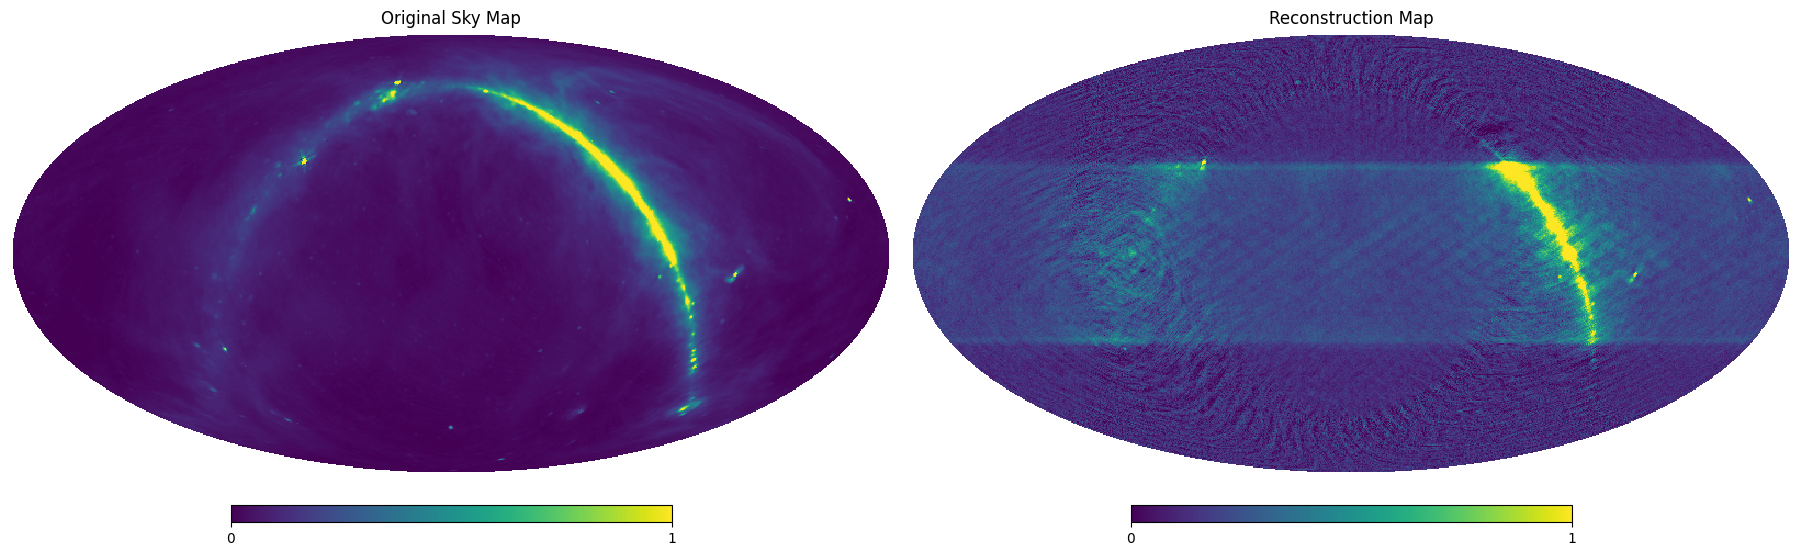

In [13]:

# =========================
# 2) 读取数据
# =========================
original = np.fromfile(ORIGINAL_PATH, dtype=np.float32)
recon    = np.fromfile(RECON_PATH, dtype=np.float32)

if original.shape != recon.shape:
    raise ValueError(f"shape mismatch: original {original.shape}, recon {recon.shape}")

npix = original.size
nside = hp.npix2nside(npix)

print(f"npix  = {npix}")
print(f"nside = {nside}")

valid_mask = np.isfinite(original) & np.isfinite(recon)

# HEALPix 像素对应纬度
pix = np.arange(npix)
theta, phi = hp.pix2ang(nside, pix, nest=NEST)
lat_deg = 90.0 - np.degrees(theta)

band_mask = valid_mask & (np.abs(lat_deg) <= BAND_LAT_DEG)

print(f"valid pixels      : {valid_mask.sum()}")
print(f"band pixels       : {band_mask.sum()}")
print(f"band lat range    : |lat| <= {BAND_LAT_DEG} deg")

# =========================
# 3) 只对 recon 做线性标定（在 band 内拟合）
# =========================
a, b, recon_aligned = linear_calibrate_recon_to_original(original, recon, band_mask)
print(f"\nLinear calibration on band:")
print(f"original ≈ a * recon + b")
print(f"a = {a}")
print(f"b = {b}")

# =========================
# 4) 画图：1x2
#    注意：这里只是显示增强，不参与指标
# =========================
original_vis = robust_display_norm(original, PLOT_P_LOW, PLOT_P_HIGH)
recon_vis    = robust_display_norm(recon_aligned, PLOT_P_LOW, PLOT_P_HIGH)

fig = plt.figure(figsize=(18, 6))

hp.mollview(
    original_vis,
    nest=NEST,
    fig=fig.number,
    sub=(1, 2, 1),
    title="Original Sky Map",
    min=0,
    max=1,
    cmap="viridis",
    cbar=True,
)

hp.mollview(
    recon_vis,
    nest=NEST,
    fig=fig.number,
    sub=(1, 2, 2),
    title="Reconstruction Map",
    min=0,
    max=1,
    cmap="viridis",
    cbar=True,
)

plt.show()


In [14]:
# =========================
# 5) 计算指标
# =========================

full_mask = valid_mask  
eval_band_mask = band_mask

# ---------- 5.1 Pearson ----------
pearson_full = masked_pearson_corr(original, recon_aligned, full_mask)
pearson_band = masked_pearson_corr(original, recon_aligned, eval_band_mask)

# ---------- 5.2 NRMSE ----------
nrmse_full, rmse_full = masked_nrmse(original, recon_aligned, full_mask, mode=NRMSE_MODE)
nrmse_band, rmse_band = masked_nrmse(original, recon_aligned, eval_band_mask, mode=NRMSE_MODE)

# ---------- 5.3 SSIM ----------
# band-limited SSIM（主指标）
original_for_ssim_band, recon_for_ssim_band = common_norm_pair(
    original, recon_aligned, eval_band_mask
)
ssim_band = region_limited_ssim(
    original_for_ssim_band,
    recon_for_ssim_band,
    lat_min_deg=-BAND_LAT_DEG,
    lat_max_deg= BAND_LAT_DEG,
    nest=NEST,
    xsize=SSIM_XSIZE,
    ysize=SSIM_YSIZE
)

# 可选：full-sky SSIM（如果你也想看）
original_for_ssim_full, recon_for_ssim_full = common_norm_pair(
    original, recon_aligned, full_mask
)
ssim_full = region_limited_ssim(
    original_for_ssim_full,
    recon_for_ssim_full,
    lat_min_deg=-90.0,
    lat_max_deg=90.0,
    nest=NEST,
    xsize=SSIM_XSIZE,
    ysize=SSIM_YSIZE
)

# ---------- 5.4 Peak location error ----------
# 主指标：full-sky peak error
peak_err_full_deg, ref_peak_full_pix, pred_peak_full_pix, ref_peak_full_ll, pred_peak_full_ll = \
    masked_peak_location_error(original, recon_aligned, full_mask, nside, nest=NEST)

# 辅助指标：band-only peak error
peak_err_band_deg, ref_peak_band_pix, pred_peak_band_pix, ref_peak_band_ll, pred_peak_band_ll = \
    masked_peak_location_error(original, recon_aligned, eval_band_mask, nside, nest=NEST)

# =========================
# 6) 输出结果
# =========================
print("\n===== Metrics =====")

print("\n[Masked Pearson correlation]")
print(f"Full-sky : {pearson_full:.6f}")
print(f"Band     : {pearson_band:.6f}")

print("\n[Masked NRMSE]")
print(f"Full-sky : {nrmse_full:.6e}   (RMSE = {rmse_full:.6e})")
print(f"Band     : {nrmse_band:.6e}   (RMSE = {rmse_band:.6e})")

print("\n[SSIM]")
print(f"Full-sky SSIM     : {ssim_full:.6f}")
print(f"Band-limited SSIM : {ssim_band:.6f}")

print("\n[Peak location error]")
print(f"Full-sky peak error (deg) : {peak_err_full_deg:.6f}")
print(f"Band peak error (deg)     : {peak_err_band_deg:.6f}")


# ---------- 5.5 Cosine similarity ----------
cosine_full = masked_cosine_similarity(original, recon_aligned, full_mask)
cosine_band = masked_cosine_similarity(original, recon_aligned, eval_band_mask)

# ---------- 5.6 Flux ratio / Total power ratio ----------
# signed
flux_ratio_full = masked_flux_ratio(original, recon_aligned, full_mask, positive_only=False)
flux_ratio_band = masked_flux_ratio(original, recon_aligned, eval_band_mask, positive_only=False)

# positive-only
pos_flux_ratio_full = masked_flux_ratio(original, recon_aligned, full_mask, positive_only=True)
pos_flux_ratio_band = masked_flux_ratio(original, recon_aligned, eval_band_mask, positive_only=True)


print("\n[Cosine similarity]")
print(f"Full-sky : {cosine_full:.6f}")
print(f"Band     : {cosine_band:.6f}")

print("\n[Flux ratio / Total power ratio]")
print("Signed total power ratio:")
print(f"  Full-sky : {flux_ratio_full:.6f}")
print(f"  Band     : {flux_ratio_band:.6f}")

print("Positive-only flux ratio:")
print(f"  Full-sky : {pos_flux_ratio_full:.6f}")
print(f"  Band     : {pos_flux_ratio_band:.6f}")

KeyboardInterrupt: 